##### Data Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/properties.csv")

In [3]:
df.head()

,id,title,price,price_display,price_per_sqft,locality,city,bhk,bathrooms,balconies,...,furnishing,floor,transaction_type,property_type,possession_status,ownership,facing,society,posted_by,url
0,85343819,3BHK Multistorey Apartment for Resale in Assot...,17000000.0,1.70 Cr,10272.0,Rudrapur,Bhubaneswar,3,3,NaN,...,Unfurnished,14 of 14 Floor,Resale,Apartment,Ready to Move,NaN,NaN,Assotech Pride,Owner,https://www.magicbricks.com/propertyDetails-3-...
1,85324987,3BHK Multistorey Apartment for Resale in,14900000.0,1.49 Cr,11920.0,NaN,Bhubaneswar,3,2,2.0,...,Unfurnished,Ground of 3 Floor,Resale,Apartment,Ready to Move,Leasehold,South,NaN,Owner,https://www.magicbricks.com/propertyDetails-3-...
2,85331583,3BHK Multistorey Apartment for Resale in DN Fa...,14000000.0,1.40 Cr,8669.0,Madanpur,Bhubaneswar,3,2,2.0,...,Semi-Furnished,5 of 14 Floor,Resale,Apartment,Ready to Move,Freehold,NaN,DN Fairytale,Owner,https://www.magicbricks.com/propertyDetails-3-...
3,85326997,3BHK Multistorey Apartment for Resale in Pokha...,12500000.0,1.25 Cr,9615.0,Pokhariput,Bhubaneswar,3,3,1.0,...,Semi-Furnished,2 of 4 Floor,Resale,Apartment,Ready to Move,Freehold,NaN,NaN,Owner,https://www.magicbricks.com/propertyDetails-3-...
4,51858951,Residential Plot for New Property in Patrapada,1650000.0,16.5 Lac,1100.0,Patrapada,Bhubaneswar,NaN,NaN,NaN,...,NaN,NaN,New Property,Residential Plot,NaN,Freehold,North - East,NaN,Owner,https://www.magicbricks.com/propertyDetails-15...


In [4]:
df.shape

(1752, 22)

In [5]:
df.columns

Index(['id', 'title', 'price', 'price_display', 'price_per_sqft', 'locality',
       'city', 'bhk', 'bathrooms', 'balconies', 'area_sqft', 'carpet_area',
       'furnishing', 'floor', 'transaction_type', 'property_type',
       'possession_status', 'ownership', 'facing', 'society', 'posted_by',
       'url'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1752 non-null   int64  
 1   title              1752 non-null   object 
 2   price              1713 non-null   float64
 3   price_display      1752 non-null   object 
 4   price_per_sqft     1678 non-null   float64
 5   locality           1682 non-null   object 
 6   city               1752 non-null   object 
 7   bhk                1308 non-null   object 
 8   bathrooms          1286 non-null   object 
 9   balconies          1051 non-null   float64
 10  area_sqft          1271 non-null   float64
 11  carpet_area        771 non-null    float64
 12  furnishing         1238 non-null   object 
 13  floor              845 non-null    object 
 14  transaction_type   1750 non-null   object 
 15  property_type      1752 non-null   object 
 16  possession_status  1279 

In [7]:
df.describe()

,id,price,price_per_sqft,balconies,area_sqft,carpet_area
count,1.752000e+03,1.713000e+03,1678.000000,1051.000000,1271.000000,771.000000
mean,7.922105e+07,1.313827e+07,6200.453516,2.067555,1889.321007,1469.582361
std,9.025151e+06,1.337889e+07,3922.109068,0.948283,902.968502,4468.946913
min,2.675089e+07,2.500000e+05,0.000000,1.000000,500.000000,194.000000
25%,7.753989e+07,6.100000e+06,4000.000000,1.000000,1369.000000,956.000000
50%,8.343802e+07,1.000000e+07,6111.000000,2.000000,1700.000000,1147.000000
75%,8.484611e+07,1.575600e+07,8009.000000,3.000000,2169.000000,1448.500000
max,8.534525e+07,2.040000e+08,73333.000000,10.000000,12000.000000,123740.000000


In [8]:
df.duplicated().sum()

0

In [9]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

carpet_area          981
society              955
floor                907
facing               867
ownership            847
balconies            701
furnishing           514
area_sqft            481
possession_status    473
bathrooms            466
bhk                  444
price_per_sqft        74
locality              70
price                 39
transaction_type       2
posted_by              0
id                     0
property_type          0
title                  0
city                   0
price_display          0
url                    0
dtype: int64

In [10]:
# Analyze missing values by percentage
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().mean() * 100).round(2)
})

missing[missing["Missing Values"] > 0].sort_values(
    by="Percentage", ascending=False
)

,Missing Values,Percentage
carpet_area,981,55.99
society,955,54.51
floor,907,51.77
facing,867,49.49
ownership,847,48.34
balconies,701,40.01
furnishing,514,29.34
area_sqft,481,27.45
possession_status,473,27.00
bathrooms,466,26.60


## Handling Missing Values

Before imputing or removing missing values, we analyze columns with missing data to decide the most appropriate cleaning strategy.

## Handle Missing Values in the Target Column

The `price` column is the target variable for this project. Since a machine learning model cannot be trained on records without a target value, rows with missing prices are removed.

In [12]:
df["price"].isnull().sum()

39

In [13]:
df = df.dropna(subset=["price"])

In [14]:
df["price"].isnull().sum()

0

In [15]:
df.shape

(1713, 22)

## Recheck Missing Values

After removing rows with missing target values, re-evaluate the missing values in the remaining dataset.

In [16]:
df.isnull().sum().sort_values(ascending=False)

carpet_area          945
society              930
floor                871
facing               830
ownership            809
balconies            667
furnishing           480
area_sqft            457
possession_status    437
bathrooms            433
bhk                  422
locality              66
price_per_sqft        35
property_type          0
posted_by              0
id                     0
transaction_type       0
title                  0
city                   0
price_display          0
price                  0
url                    0
dtype: int64

## Remove Columns with Excessive Missing Values

The `carpet_area` and `society` columns contain more than 50% missing values and provide limited information for most records. Therefore, these columns are removed from the dataset.

In [17]:
df.drop(columns=["carpet_area", "society"], inplace=True)

In [18]:
df.columns

Index(['id', 'title', 'price', 'price_display', 'price_per_sqft', 'locality',
       'city', 'bhk', 'bathrooms', 'balconies', 'area_sqft', 'furnishing',
       'floor', 'transaction_type', 'property_type', 'possession_status',
       'ownership', 'facing', 'posted_by', 'url'],
      dtype='object')

## Handle Missing Values in `price_per_sqft`

Since `price_per_sqft` is a derived feature, missing values can be calculated using the available `price` and `area_sqft` values whenever possible.

In [19]:
df["price_per_sqft"].isnull().sum()

35

In [20]:
df[df["price_per_sqft"].isnull()][["price", "area_sqft", "price_per_sqft"]]

,price,area_sqft,price_per_sqft
13,16600000.0,NaN,NaN
20,25000000.0,NaN,NaN
31,7700000.0,NaN,NaN
74,8500000.0,NaN,NaN
173,17000000.0,NaN,NaN
232,9500000.0,NaN,NaN
248,22000000.0,NaN,NaN
314,6800000.0,NaN,NaN
407,16000000.0,NaN,NaN
449,50000000.0,NaN,NaN


## Handle Missing Values in `area_sqft`

The `area_sqft` feature is an important predictor of property price. Before imputing missing values, we inspect the distribution of the available values.

In [21]:
df["area_sqft"].describe()

count     1256.000000
mean      1895.387739
std        903.778680
min        500.000000
25%       1373.750000
50%       1700.000000
75%       2171.750000
max      12000.000000
Name: area_sqft, dtype: float64

In [22]:
df["area_sqft"].median()

1700.0

<Axes: >

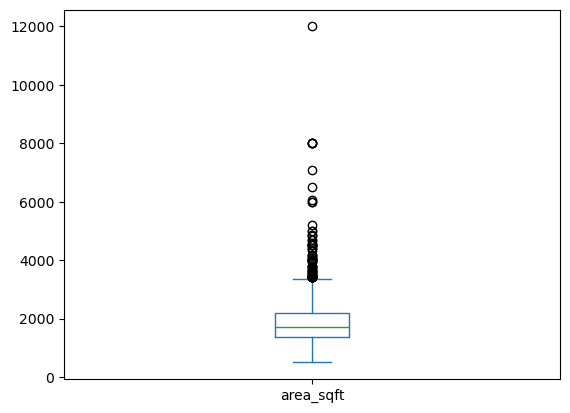

In [23]:
df["area_sqft"].plot(kind="box")

## Impute Missing Values in `area_sqft`

The `area_sqft` column contains missing values and exhibits a right-skewed distribution with several outliers. Since the median is less affected by outliers than the mean, missing values are imputed using the median area.

In [24]:
df["area_sqft"] = df["area_sqft"].fillna(df["area_sqft"].median())

In [25]:
df["area_sqft"].isnull().sum()

0

In [26]:
df["area_sqft"].describe()

count     1713.000000
mean      1843.261529
std        778.619110
min        500.000000
25%       1497.000000
50%       1700.000000
75%       1901.000000
max      12000.000000
Name: area_sqft, dtype: float64

## Handle Missing Values in `price_per_sqft`

The `price_per_sqft` column is a derived feature calculated using the property price and area. Since the missing values in `area_sqft` have been imputed, the missing values in `price_per_sqft` can now be computed using the available `price` and `area_sqft` values.

In [27]:
df["price_per_sqft"] = df["price_per_sqft"].fillna(
    df["price"] / df["area_sqft"]
)

In [28]:
df["price_per_sqft"].isnull().sum()

0

## Handle Missing Values in `bhk`

The `bhk` column is an important feature representing the number of bedrooms. Before imputing missing values, we inspect the distribution of existing values.

In [29]:
df["bhk"].value_counts(dropna=False)

3       739
NaN     422
2       282
4       173
5        32
1        25
6        18
8         5
7         5
> 10      5
9         4
10        3
Name: bhk, dtype: int64

In [30]:
df["bhk"].mode()

0    3
Name: bhk, dtype: object

In [31]:
df[df["bhk"].isnull()]["property_type"].value_counts()

Residential Plot     417
Studio Apartment       2
Residential House      2
Apartment              1
Name: property_type, dtype: int64

In [32]:
df.loc[
    (df["property_type"] == "Residential Plot") & (df["bhk"].isnull()),
    "bhk"
] = 0

In [33]:
df = df.dropna(subset=["bhk"])

In [34]:
df["bhk"].isnull().sum()

0

## Handle Missing Values in `bathrooms`

The `bathrooms` column is an important feature for predicting property prices. Before imputing missing values, we analyze which property types contain missing values to choose an appropriate cleaning strategy.

In [35]:
df[df["bathrooms"].isnull()]["property_type"].value_counts()

Residential Plot     417
Villa                  6
Apartment              4
Residential House      3
Name: property_type, dtype: int64

In [36]:
df.loc[
    (df["property_type"] == "Residential Plot") & (df["bathrooms"].isnull()),
    "bathrooms"
] = 0

In [37]:
df = df.dropna(subset=["bathrooms"])

In [38]:
df["bathrooms"].isnull().sum()

0

## Handle Missing Values in `balconies`

The `balconies` feature may not be applicable to all property types. Before imputing or removing missing values, we analyze which property types contain missing values.

In [39]:
df[df["balconies"].isnull()]["property_type"].value_counts()

Residential Plot           417
Apartment                  152
Residential House           37
Villa                       21
Builder Floor Apartment     21
Penthouse                    3
Name: property_type, dtype: int64

In [40]:
df.drop(columns=["balconies"], inplace=True)

In [41]:
df.columns

Index(['id', 'title', 'price', 'price_display', 'price_per_sqft', 'locality',
       'city', 'bhk', 'bathrooms', 'area_sqft', 'furnishing', 'floor',
       'transaction_type', 'property_type', 'possession_status', 'ownership',
       'facing', 'posted_by', 'url'],
      dtype='object')

## Handle Missing Values in `furnishing`

The `furnishing` column is an important categorical feature that may influence property prices. Before imputing missing values, we analyze the distribution of furnishing status across different property types.

In [42]:
df[df["furnishing"].isnull()]["property_type"].value_counts()

Residential Plot           417
Apartment                   33
Residential House           12
Villa                        6
Builder Floor Apartment      5
Name: property_type, dtype: int64

In [43]:
df.loc[
    (df["property_type"] == "Residential Plot") & (df["furnishing"].isnull()),
    "furnishing"
] = "Not Applicable"

In [44]:
df.groupby("property_type")["furnishing"].value_counts()

property_type            furnishing    
Apartment                Unfurnished       636
                         Semi-Furnished    298
                         Furnished          93
Builder Floor Apartment  Unfurnished        14
                         Furnished           8
                         Semi-Furnished      5
Penthouse                Unfurnished         4
                         Semi-Furnished      1
Residential House        Semi-Furnished     33
                         Unfurnished        25
                         Furnished          14
Residential Plot         Not Applicable    417
Villa                    Unfurnished        57
                         Semi-Furnished     26
                         Furnished           8
Name: furnishing, dtype: int64

In [45]:
furnishing_mode = (
    df.groupby("property_type")["furnishing"]
      .agg(lambda x: x.mode()[0])
)

In [46]:
df["furnishing"] = df.apply(
    lambda row: furnishing_mode[row["property_type"]]
    if pd.isna(row["furnishing"])
    else row["furnishing"],
    axis=1
)

In [47]:
df["furnishing"].isnull().sum()

0

In [48]:
df.isnull().sum().sort_values(ascending=False)

floor                853
facing               812
ownership            791
possession_status    432
locality              64
id                     0
furnishing             0
posted_by              0
property_type          0
transaction_type       0
area_sqft              0
title                  0
bathrooms              0
bhk                    0
city                   0
price_per_sqft         0
price_display          0
price                  0
url                    0
dtype: int64

## Handle Missing Values in `locality`

The dataset contains properties only from Bhubaneswar. Since the `locality` column has a small number of missing values, they are imputed using the most frequent locality (mode).

In [49]:
df["locality"].mode()

0    Patia
Name: locality, dtype: object

In [50]:
df["locality"] = df["locality"].fillna(df["locality"].mode()[0])

In [51]:
df["locality"].isnull().sum()

0

## Handle Missing Values in `possession_status`

Most missing values in the `possession_status` column belong to residential plots, where possession status is not applicable. These values are assigned as "Not Applicable". The remaining missing values are imputed using the most frequent possession status.

In [52]:
df.loc[
    (df["property_type"] == "Residential Plot") &
    (df["possession_status"].isnull()),
    "possession_status"
] = "Not Applicable"

In [53]:
df["possession_status"].mode()

0    Ready to Move
Name: possession_status, dtype: object

In [54]:
df["possession_status"] = df["possession_status"].fillna(
    df["possession_status"].mode()[0]
)

In [55]:
df["possession_status"].isnull().sum()

0

In [56]:
df[df["floor"].isnull()]["property_type"].value_counts()

Residential Plot           417
Apartment                  267
Villa                       97
Residential House           65
Builder Floor Apartment      5
Penthouse                    2
Name: property_type, dtype: int64

In [57]:
df[df["facing"].isnull()]["property_type"].value_counts()

Apartment                  486
Residential Plot           213
Residential House           49
Villa                       36
Builder Floor Apartment     25
Penthouse                    3
Name: property_type, dtype: int64

In [58]:
df[df["ownership"].isnull()]["property_type"].value_counts()

Apartment                  472
Residential Plot           204
Residential House           49
Villa                       38
Builder Floor Apartment     25
Penthouse                    3
Name: property_type, dtype: int64

## Handle Missing Values in `floor`

The `floor` feature is not applicable to residential plots, as plots do not have floors. Therefore, missing values for residential plots are assigned as "Not Applicable". The remaining missing values are imputed using the most frequent floor category (mode).

In [59]:
df.loc[
    (df["property_type"] == "Residential Plot") &
    (df["floor"].isnull()),
    "floor"
] = "Not Applicable"

In [60]:
df["floor"].mode()

0    Not Applicable
Name: floor, dtype: object

In [61]:
floor_mode = df.loc[
    df["floor"] != "Not Applicable",
    "floor"
].mode()[0]

In [62]:
df["floor"] = df["floor"].fillna(floor_mode)

## Cleaning floor

In [63]:
df["floor"].value_counts()

3 of 4 Floor                  508
Not Applicable                417
1 of 4 Floor                   60
2 of 4 Floor                   59
4 of 4 Floor                   52
                             ... 
14 of 17 Floor                  1
Lower Basement of 1 Floor       1
Lower Basement of 42 Floor      1
5 of 38 Floor                   1
1 of 23 Floor                   1
Name: floor, Length: 213, dtype: int64

In [64]:
df['floor'].unique()

array(['14 of 14 Floor', 'Ground of 3 Floor', '5 of 14 Floor',
       '2 of 4 Floor', 'Not Applicable', '3 of 4 Floor', '1 of 9 Floor',
       '2 of 7 Floor', '7 of 8 Floor', 'Ground of 15 Floor',
       '2 of 22 Floor', '1 of 10 Floor', '1 of 4 Floor', '2 of 3 Floor',
       '5 of 6 Floor', '2 of 5 Floor', '4 of 4 Floor', '2 of 9 Floor',
       '1 of 2 Floor', '13 of 20 Floor', '10 of 20 Floor', '1 of 3 Floor',
       '7 of 16 Floor', '5 of 11 Floor', '3 of 5 Floor', '4 of 5 Floor',
       '16 of 16 Floor', '2 of 8 Floor', 'Ground of 8 Floor',
       '1 of 12 Floor', '5 of 12 Floor', '9 of 14 Floor', '9 of 11 Floor',
       '2 of 11 Floor', '4 of 12 Floor', '11 of 15 Floor',
       '6 of 11 Floor', '1 of 6 Floor', '2 of 12 Floor', '3 of 3 Floor',
       'Lower Basement of 20 Floor', '4 of 21 Floor', '5 of 31 Floor',
       '7 of 17 Floor', '5 of 5 Floor', '3 of 6 Floor', '10 of 14 Floor',
       'Ground of 11 Floor', '7 of 14 Floor', '1 of 20 Floor',
       '1 of 5 Floor', '18 of 20 F

## Handle Missing Values in `facing`

The `facing` column contains missing values. Since the direction a property faces is applicable to all property types, the missing values are imputed using the most frequent category (mode).

In [65]:
df["facing"].mode()

0    East
Name: facing, dtype: object

In [66]:
df["facing"] = df["facing"].fillna(df["facing"].mode()[0])

In [67]:
df["facing"].isnull().sum()

0

## Handle Missing Values in `ownership`

The `ownership` column represents the legal ownership type of a property. Since ownership is applicable to all property types, missing values are imputed using the most frequent ownership category (mode).

In [68]:
df["ownership"].mode()

0    Freehold
Name: ownership, dtype: object

In [69]:
df["ownership"] = df["ownership"].fillna(df["ownership"].mode()[0])

In [70]:
df["ownership"].isnull().sum()

0

## Verify Missing Values

After handling all missing values and removing unnecessary columns, we verify that the dataset no longer contains any missing values.

In [71]:
df.isnull().sum()

id                   0
title                0
price                0
price_display        0
price_per_sqft       0
locality             0
city                 0
bhk                  0
bathrooms            0
area_sqft            0
furnishing           0
floor                0
transaction_type     0
property_type        0
possession_status    0
ownership            0
facing               0
posted_by            0
url                  0
dtype: int64

In [72]:
df.isnull().sum().sum()

0

In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1695 entries, 0 to 1751
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1695 non-null   int64  
 1   title              1695 non-null   object 
 2   price              1695 non-null   float64
 3   price_display      1695 non-null   object 
 4   price_per_sqft     1695 non-null   float64
 5   locality           1695 non-null   object 
 6   city               1695 non-null   object 
 7   bhk                1695 non-null   object 
 8   bathrooms          1695 non-null   object 
 9   area_sqft          1695 non-null   float64
 10  furnishing         1695 non-null   object 
 11  floor              1695 non-null   object 
 12  transaction_type   1695 non-null   object 
 13  property_type      1695 non-null   object 
 14  possession_status  1695 non-null   object 
 15  ownership          1695 non-null   object 
 16  facing             1695 

In [74]:
df.shape

(1695, 19)

## Remove Irrelevant Features

Some columns such as unique identifiers, URLs, and duplicate representations of the target variable do not contribute to predicting property prices. These columns are removed from the dataset.

In [75]:
df["posted_by"].value_counts()

Agent      813
Owner      752
Builder    130
Name: posted_by, dtype: int64

In [76]:
df["city"].nunique()

1

In [77]:
df.groupby("posted_by")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
posted_by,,,,,,,,
Agent,813.0,1.495946e+07,9.927809e+06,1050000.0,9000000.0,12736700.0,18427000.0,97000000.0
Builder,130.0,1.092156e+07,6.022359e+06,2100000.0,7954012.5,9883250.0,13328500.0,34680500.0
Owner,752.0,1.124829e+07,1.598633e+07,250000.0,4000000.0,7500000.0,12061500.0,204000000.0


In [78]:
df.drop(
    columns=["id", "title", "price_display", "url","city"],
    inplace=True
)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1695 entries, 0 to 1751
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              1695 non-null   float64
 1   price_per_sqft     1695 non-null   float64
 2   locality           1695 non-null   object 
 3   bhk                1695 non-null   object 
 4   bathrooms          1695 non-null   object 
 5   area_sqft          1695 non-null   float64
 6   furnishing         1695 non-null   object 
 7   floor              1695 non-null   object 
 8   transaction_type   1695 non-null   object 
 9   property_type      1695 non-null   object 
 10  possession_status  1695 non-null   object 
 11  ownership          1695 non-null   object 
 12  facing             1695 non-null   object 
 13  posted_by          1695 non-null   object 
dtypes: float64(3), object(11)
memory usage: 198.6+ KB


## Converting datatype of `bhk` and `bathrooms`

In [80]:
df['bhk'].unique()

array(['3', 0, '4', '2', '8', '5', '1', '6', '10', '7', '> 10', '9'],
      dtype=object)

In [81]:
# Replace '> 10' with 11
df["bhk"] = df["bhk"].replace("> 10", "11")

In [82]:
df['bhk'].unique()

array(['3', 0, '4', '2', '8', '5', '1', '6', '10', '7', '11', '9'],
      dtype=object)

In [83]:
# Convert BHK to nullable integer type
df["bhk"] = pd.to_numeric(df["bhk"], errors="coerce").astype("Int64")

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1695 entries, 0 to 1751
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              1695 non-null   float64
 1   price_per_sqft     1695 non-null   float64
 2   locality           1695 non-null   object 
 3   bhk                1695 non-null   Int64  
 4   bathrooms          1695 non-null   object 
 5   area_sqft          1695 non-null   float64
 6   furnishing         1695 non-null   object 
 7   floor              1695 non-null   object 
 8   transaction_type   1695 non-null   object 
 9   property_type      1695 non-null   object 
 10  possession_status  1695 non-null   object 
 11  ownership          1695 non-null   object 
 12  facing             1695 non-null   object 
 13  posted_by          1695 non-null   object 
dtypes: Int64(1), float64(3), object(10)
memory usage: 200.3+ KB


#### Bathrooms

In [85]:
df['bathrooms'].unique()

array(['3', '2', 0, '8', '5', '4', '1', '10', '6', '> 10', '7', '9'],
      dtype=object)

In [86]:
df["bathrooms"].value_counts()

3       539
2       475
0       417
4       157
5        50
1        29
6        14
8         4
> 10      3
7         3
9         3
10        1
Name: bathrooms, dtype: int64

In [87]:
df[df["bathrooms"] == "> 10"][
    ["property_type", "bhk", "bathrooms", "area_sqft", "price"]
]

,property_type,bhk,bathrooms,area_sqft,price
912,Residential House,11,> 10,7100.0,70000000.0
1082,Apartment,4,> 10,2995.0,31747000.0
1252,Builder Floor Apartment,11,> 10,12000.0,90000000.0


In [88]:
df["bathrooms"] = df["bathrooms"].replace("> 10", 11)

In [89]:
df["bathrooms"] = df["bathrooms"].astype(int)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1695 entries, 0 to 1751
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   price              1695 non-null   float64
 1   price_per_sqft     1695 non-null   float64
 2   locality           1695 non-null   object 
 3   bhk                1695 non-null   Int64  
 4   bathrooms          1695 non-null   int32  
 5   area_sqft          1695 non-null   float64
 6   furnishing         1695 non-null   object 
 7   floor              1695 non-null   object 
 8   transaction_type   1695 non-null   object 
 9   property_type      1695 non-null   object 
 10  possession_status  1695 non-null   object 
 11  ownership          1695 non-null   object 
 12  facing             1695 non-null   object 
 13  posted_by          1695 non-null   object 
dtypes: Int64(1), float64(3), int32(1), object(9)
memory usage: 193.7+ KB


In [91]:
df.head()

,price,price_per_sqft,locality,bhk,bathrooms,area_sqft,furnishing,floor,transaction_type,property_type,possession_status,ownership,facing,posted_by
0,17000000.0,10272.0,Rudrapur,3,3,1655.0,Unfurnished,14 of 14 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
1,14900000.0,11920.0,Patia,3,2,1250.0,Unfurnished,Ground of 3 Floor,Resale,Apartment,Ready to Move,Leasehold,South,Owner
2,14000000.0,8669.0,Madanpur,3,2,1615.0,Semi-Furnished,5 of 14 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
3,12500000.0,9615.0,Pokhariput,3,3,1300.0,Semi-Furnished,2 of 4 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
4,1650000.0,1100.0,Patrapada,0,0,1700.0,Not Applicable,Not Applicable,New Property,Residential Plot,Not Applicable,Freehold,North - East,Owner


### Final check of the cleaned dataset

In [94]:
df.isnull().sum().sum()

0

In [96]:
df.duplicated().sum()

65

In [97]:
df[df.duplicated(keep=False)]

,price,price_per_sqft,locality,bhk,bathrooms,area_sqft,furnishing,floor,transaction_type,property_type,possession_status,ownership,facing,posted_by
15,5800000.0,3984.0,Sundarpada,3,2,1456.0,Unfurnished,1 of 10 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
30,3600000.0,1800.0,Tamando,0,0,1700.0,Not Applicable,Not Applicable,Resale,Residential Plot,Not Applicable,Freehold,East,Agent
363,50000000.0,6250.0,Lumbini Vihar,6,5,8000.0,Unfurnished,3 of 4 Floor,Resale,Villa,Ready to Move,Freehold,East,Owner
365,50000000.0,6250.0,Lumbini Vihar,6,5,8000.0,Unfurnished,3 of 4 Floor,Resale,Villa,Ready to Move,Freehold,East,Owner
405,5800000.0,3984.0,Sundarpada,3,2,1456.0,Unfurnished,1 of 10 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1720,20378000.0,9263.0,Sundarpur,3,3,2200.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Nov '27,Freehold,East,Agent
1721,20400000.0,9315.0,Sundarpur,3,3,2190.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Nov '27,Freehold,East,Agent
1722,30627000.0,10226.0,Sundarpur,4,4,2995.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Nov '27,Freehold,East,Agent
1723,23204000.0,9811.0,Sundarpur,3,3,2365.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Nov '27,Freehold,East,Agent


In [98]:
df[df.duplicated(keep=False)].sort_values(
    by=["locality", "property_type", "bhk", "area_sqft"]
).head(20)

,price,price_per_sqft,locality,bhk,bathrooms,area_sqft,furnishing,floor,transaction_type,property_type,possession_status,ownership,facing,posted_by
813,4000000.0,3636.0,Chandaka,3,2,1100.0,Semi-Furnished,9 of 11 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
823,4000000.0,3636.0,Chandaka,3,2,1100.0,Semi-Furnished,9 of 11 Floor,Resale,Apartment,Ready to Move,Freehold,East,Owner
1655,22500000.0,11250.0,Daruthenga,4,3,2000.0,Unfurnished,3 of 4 Floor,New Property,Villa,Under Construction,Freehold,North,Agent
1657,22500000.0,11250.0,Daruthenga,4,3,2000.0,Unfurnished,3 of 4 Floor,New Property,Villa,Under Construction,Freehold,North,Agent
852,49090000.0,14291.0,Gadakana,4,4,3435.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Feb '29,Freehold,East,Agent
1603,49090000.0,14291.0,Gadakana,4,4,3435.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Feb '29,Freehold,East,Agent
850,55900000.0,15273.0,Gadakana,4,4,3660.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Feb '29,Freehold,East,Agent
1602,55900000.0,15273.0,Gadakana,4,4,3660.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Feb '29,Freehold,East,Agent
466,7884000.0,6000.0,Ghangapatna,2,2,1314.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Dec '29,Freehold,East,Agent
1160,7884000.0,6000.0,Ghangapatna,2,2,1314.0,Unfurnished,3 of 4 Floor,New Property,Apartment,Dec '29,Freehold,East,Agent


## Remove Duplicate Records

After removing identifier columns (`id`, `title`, `price_display`, and `url`), some records became identical across all remaining features. Since these rows contain the same feature values and target value, they do not provide additional information for model training. Therefore, exact duplicate records are removed.

In [99]:
df = df.drop_duplicates().reset_index(drop=True)

In [100]:
df.duplicated().sum()

0

In [101]:
df.shape

(1630, 14)

In [102]:
df.describe()

,price,price_per_sqft,bhk,bathrooms,area_sqft
count,1.630000e+03,1630.000000,1630.000000,1630.000000,1630.000000
mean,1.285727e+07,6179.020534,2.298160,2.158896,1822.825153
std,1.293105e+07,3984.053326,1.641821,1.568538,753.545846
min,2.500000e+05,0.000000,0.000000,0.000000,500.000000
25%,6.050250e+06,4000.000000,1.000000,1.000000,1480.000000
50%,1.000000e+07,6045.500000,3.000000,2.000000,1700.000000
75%,1.537800e+07,8000.000000,3.000000,3.000000,1885.500000
max,2.040000e+08,73333.000000,11.000000,11.000000,12000.000000


## Save the Cleaned Dataset

The cleaned dataset is saved for use in the Feature Engineering and Exploratory Data Analysis stages.

In [104]:
df.to_csv("../data/cleaned_properties.csv", index=False)